# 01 - Object Detection

Ejemplos de deteccion con salida en `DataFrame` y ploteo directo. Las funciones de `vision.yolo.plotting` muestran el grafico y, si pasas `save_to`, guardan PNG sin que tengas que manipular objetos `Figure`.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = (
    str(NOTEBOOK_DIR / "bus.jpg")
    if (NOTEBOOK_DIR / "bus.jpg").exists()
    else "https://ultralytics.com/images/bus.jpg"
)

from vision.yolo.infer import predict_image, predict_images, predict_directory
from vision.yolo.devices import detect_device, get_device_info
from vision.yolo.plotting import (
    plot_class_distribution,
    plot_image_detections,
    plot_bounding_boxes,
)

MODEL = (
    str(NOTEBOOK_DIR / "yolo11n.pt")
    if (NOTEBOOK_DIR / "yolo11n.pt").exists()
    else "yolo11n.pt"
)
print("device:", detect_device())
print(get_device_info())


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda:0
DeviceInfo(device='cuda:0', cuda_available=True, cuda_device_count=1, cuda_device_name='NVIDIA GeForce RTX 3060', cuda_total_memory_mb=11910.0625, cuda_free_memory_mb=10755.75, cpu_count=16, ram_total_mb=31967.5390625, ram_available_mb=19973.4765625)


In [ ]:
# Deteccion en una imagen
df = predict_image(MODEL, IMAGE, confidence=0.25)
print(df.head())
print("detections:", len(df))


   frame track_id  class_id class_name  confidence        xmin        ymin  \
0      0     None         5        bus    0.940240    3.824118  229.363373   
1      0     None         0     person    0.888143  671.028259  394.839966   
2      0     None         0     person    0.878327   47.417885  399.567535   
3      0     None         0     person    0.855737  223.061310  408.692383   
4      0     None         0     person    0.621978    0.021913  556.086853   

         xmax        ymax polygon  mask keypoints timestamp  
0  796.216797  728.419250    None  None      None      None  
1  809.809692  878.717407    None  None      None      None  
2  239.303421  904.201294    None  None      None      None  
3  344.463654  860.434387    None  None      None      None  
4   68.859329  872.374451    None  None      None      None  
detections: 5


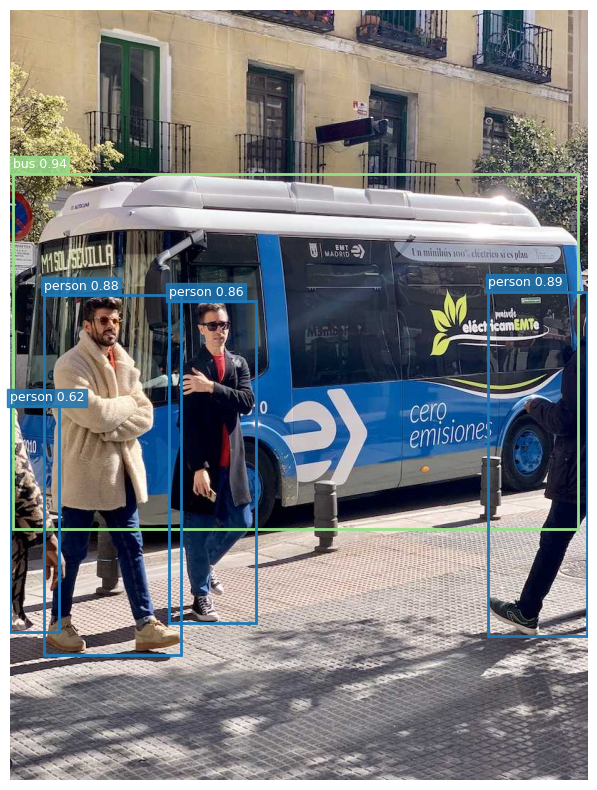

In [ ]:
# Plot directo sobre la imagen y guardado a PNG
plot_image_detections(
    IMAGE,
    df,
    confidence_threshold=0.25,
    save_to=OUTPUT_DIR / "01_image_detections.png",
)


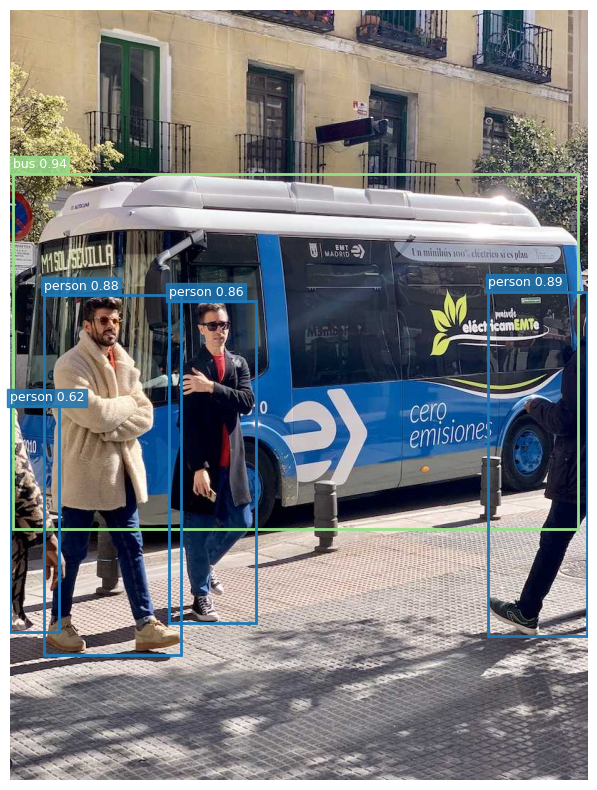

In [ ]:
# Solo cajas, util cuando no queres superponer otros tipos de salida
plot_bounding_boxes(
    IMAGE,
    df,
    max_detections=10,
    save_to=OUTPUT_DIR / "01_boxes_only.png",
)


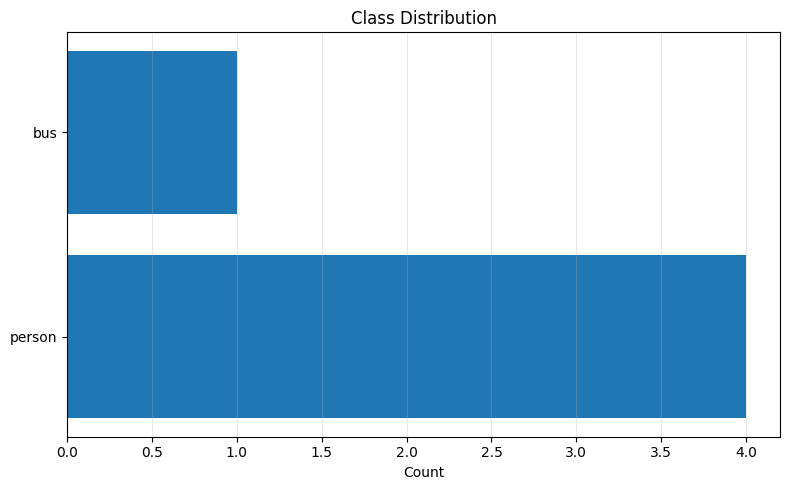

In [ ]:
# Resumen simple por clase
plot_class_distribution(df, save_to=OUTPUT_DIR / "01_class_distribution.png")


  class_name  confidence        xmin        ymin        xmax        ymax
1     person    0.888143  671.028259  394.839966  809.809692  878.717407
2     person    0.878327   47.417885  399.567535  239.303421  904.201294
3     person    0.855737  223.061310  408.692383  344.463654  860.434387
4     person    0.621978    0.021913  556.086853   68.859329  872.374451


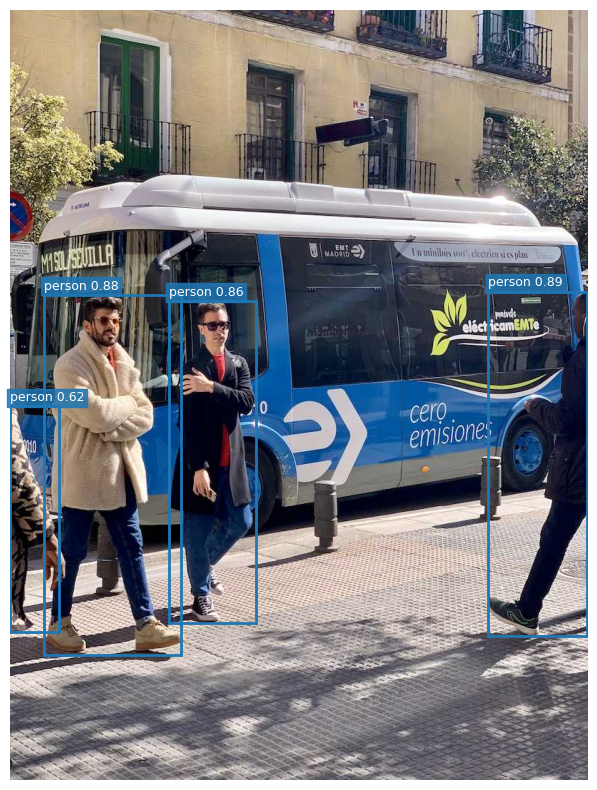

In [ ]:
# Filtrado pandas antes de plotear
people = df[df["class_name"].eq("person") & df["confidence"].ge(0.35)]
print(people[["class_name", "confidence", "xmin", "ymin", "xmax", "ymax"]])
plot_image_detections(IMAGE, people, save_to=OUTPUT_DIR / "01_people_filtered.png")


In [ ]:
# Batch de imagenes. Reemplaza por tus rutas locales.
images = [IMAGE, IMAGE]
batch_df = predict_images(MODEL, images, batch_size=2, confidence=0.25)
print(batch_df.groupby("frame").size())


frame
0    5
1    5
dtype: int64


In [ ]:
# Directorio completo. Cambia pattern si usas .png, .jpeg, etc.
# directory_df = predict_directory(MODEL, "path/to/images", pattern="*.jpg", confidence=0.25)
# print(directory_df.head())
